# RQ-E-1 — dismiss detector `icon_only` ablation → Axis B activation pool 회복량

**plane D · authority NON_CANONICAL · claim_kind ANALYSIS**

`l0_probe.js:402` 의 `icon_only` 조건을 끄면 Axis B 의 activation pool 이 얼마나 회복되는가를
**재수집 없이** frozen probe raw 재계산으로 잰다.

- 코드 독해 SHA: `2281c853950d0c475c5d2c1678680b971c2804f4` (읽기 전용, 실행하지 않음)
- **인과 주장 없음** — 코드를 고쳐 돌린 것이 아니라 filter 항을 뺀 반사실 재계산이다.
- GO/NO_GO · threshold · 수정 권고 없음 (construct 는 A 권한)
- firewall: `D_INPUT_ALLOWLIST.json` 의 denied 목록을 하나도 열지 않았다. 네트워크 없음.

경쟁가설 4개를 전부 세우고 각각 판정한다:
`H-E1-RECOVERY` / `H-E1-NULL` / `H-E1-HARM` / `H-E1-IRRELEVANT`.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d")
sys.path.insert(0, str(RD / "tools"))
import rq_e1_icononly_ablation as E

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 60)
print("code SHA read:", E.CODE_SHA)
print("seed:", E.SEED, "| parent run:", E.PARENT_RUN_ID)

code SHA read: 2281c853950d0c475c5d2c1678680b971c2804f4
seed: 20260828 | parent run: 27d10a01df5442b681ee73062e01c123


## 1. 사전 고정 정의

측정 **전에** 정의를 박는다. 특히 grain 을 섞지 않는다 — target grain 과 candidate grain 은 분모가 다르다.

In [2]:
for k, v in E.DEFINITIONS.items():
    print(f"- {k}\n    {v}\n")

- grain_dismiss_entry
    probe raw `dismiss_control_candidates[*].dismiss_control_candidates[*]` 의 원소 1개. 같은 selector 가 서로 다른 container 에서 두 번 나올 수 있으므로 selector 와 1:1 이 아니다.

- grain_dismiss_selector
    target 안에서 selector 문자열 1개. l1_engine.py:346-350 이 실제로 만드는 것은 **selector 문자열의 set** 이므로, 같은 selector 의 여러 entry 는 flag 를 OR 로 합친 것과 동치다. baseline/ablation 집합은 이 grain 에서 정의한다.

- grain_pac_hittable
    `primary_action_candidates` 중 `hittable==true` 이고 selector 가 있는 원소 1개. l1_engine.py:352-356 의 후보 필터와 같다. Axis B activation pool 의 분모다.

- grain_target
    in_mart==1 이며 l0a/probe.json 을 가진 web target 1개 (n=54).

- baseline_dismiss_set
    D_base(t) = { selector : 그 selector 의 entry 가 probe 에 하나라도 존재 }. probe 가 이미 l0_probe.js:409 `matches_close_vocabulary || icon_only` 로 걸러 저장하므로, 저장된 entry 는 전부 둘 중 하나를 만족한다.

- ablated_dismiss_set
    D_abl(t) = { selector : 그 selector 의 entry 중 하나라도 matches_close_vocabulary==true }. l0_probe.js:409 의 filter 를 `x.matches_close_vocabulary` 만으로 바꾼 반사실이다.

## 2. 반사실 재계산

`l0_probe.js:409` 의 `filter(x => x.matches_close_vocabulary || x.icon_only)` 에서
`|| x.icon_only` 를 뺀 집합을 계산하고, `l1_engine.py:346-357` 의 selector-set 차집합을 재현한다.

`l1_engine` 이 만드는 것은 **selector 문자열의 set** 이므로, 같은 selector 의 여러 entry 는
flag 를 OR 로 합친 것과 동치다. 이 분석은 그 grain 을 따른다.

In [3]:
doc, ptp, rm, sv = E.main()   # MLflow 기록 없이 계산만 재현
print("verdict:", doc["verdict"])
for k, v in doc["hypothesis_verdicts"].items():
    print(f"  {k:<20} {v['verdict']}")

verdict: PARTIALLY_SUPPORTED
  H-E1-RECOVERY        SUPPORTED
  H-E1-NULL            REFUTED
  H-E1-HARM            NOT_SUPPORTED
  H-E1-IRRELEVANT      SUPPORTED


## 3. 중복 근거 분해 — 제거된 후보를 3분할

`icon_only만` / `close_vocabulary만` / `둘 다`. 이것이 `H-E1-NULL`(중복근거이므로 회복이 미미하다) 의 직접 검정이다.

In [4]:
dup = doc["duplicate_basis_decomposition"]
print("denominator (removed hittable pac):", dup["denominator_removed"])
print(pd.DataFrame(dup["cells"]).T[["numerator", "denominator", "rate", "wilson95"]])
print()
print("entry vs selector grain:", json.dumps(dup["entry_grain_check"], ensure_ascii=False, indent=1))
print()
print("PILOT-E 대조:", json.dumps(dup["pilot_e_comparison"]["pilot_e_reported"], ensure_ascii=False))

denominator (removed hittable pac): 57


                      numerator denominator    rate          wilson95
icon_only_only               35          57   0.614  [0.4843, 0.7294]
close_vocabulary_only        17          57  0.2982  [0.1953, 0.4266]
both                          5          57  0.0877  [0.0381, 0.1895]

entry vs selector grain: {
 "note": "selector 가 여러 container 에 중복 등장하면 entry grain 과 selector grain 이 갈린다.",
 "n_dismiss_entries_all": 483,
 "n_distinct_selector_target_pairs": 395,
 "n_selectors_with_multiple_entries": 60,
 "n_removed_selectors_with_multiple_entries": 6
}

PILOT-E 대조: {"icon_only": 35, "close_vocabulary": 22}


## 4. 회복량

분모를 두 개 병기한다: `제거된 후보 57` 과 `hittable 후보 전체 854`.

In [5]:
cg = doc["ablation_recovery"]["candidate_grain"]
tg = doc["ablation_recovery"]["target_grain"]
print("── candidate grain ──")
for k in ["n_hittable_candidates", "n_recovered", "pool_baseline_total", "pool_ablated_total", "pool_growth_pct"]:
    print(f"  {k:<28} {cg[k]}")
for k in ["n_removed_baseline", "n_removed_ablated", "recovery_rate_of_removed", "recovery_rate_of_all_hittable"]:
    f = cg[k]; print(f"  {k:<28} {f['numerator']}/{f['denominator']} = {f['rate']}  Wilson95 {f['wilson95']}  [{f['grain']}]")
print("\n── target grain ──")
for k in ["n_targets_pool_emptied_baseline", "n_targets_pool_emptied_ablated", "n_targets_with_any_recovery"]:
    f = tg[k]; print(f"  {k:<34} {f['numerator']}/{f['denominator']} = {f['rate']}  [{f['grain']}]")
print("  pool 이 비었던 target 중 비지 않게 되는 수:", tg["n_emptied_targets_that_unempty"])
print("  단조성 점검(P_base ⊆ P_abl):", tg["monotonicity_check"]["pool_never_shrinks"])
print()
print(pd.DataFrame(tg["emptied_target_detail"]))

── candidate grain ──
  n_hittable_candidates        854
  n_recovered                  35
  pool_baseline_total          797
  pool_ablated_total           832
  pool_growth_pct              4.3915
  n_removed_baseline           57/854 = 0.0667  Wilson95 [0.0519, 0.0855]  [hittable pac]
  n_removed_ablated            22/854 = 0.0258  Wilson95 [0.0171, 0.0387]  [hittable pac]
  recovery_rate_of_removed     35/57 = 0.614  Wilson95 [0.4843, 0.7294]  [removed hittable pac]
  recovery_rate_of_all_hittable 35/854 = 0.041  Wilson95 [0.0296, 0.0565]  [hittable pac]

── target grain ──
  n_targets_pool_emptied_baseline    5/54 = 0.0926  [target]
  n_targets_pool_emptied_ablated     0/54 = 0.0  [target]
  n_targets_with_any_recovery        22/54 = 0.4074  [target]
  pool 이 비었던 target 중 비지 않게 되는 수: 5
  단조성 점검(P_base ⊆ P_abl): True

                wtg  n_hittable  n_removed_base  pool_base  n_recovered  pool_abl  emptied_abl
0  e7bb158c1c8d9fe7         2.0             2.0        0.0          1.0

**주의** — pool 이 비었던 5 target 은 애초에 `n_hittable` 이 2~3 으로 매우 작다.
"빈 pool 이 전부 회복된다" 는 문장은 그 5 target 이 원래 후보가 거의 없던 페이지였다는 사실과
함께 읽어야 한다.

In [6]:
side = doc["ablation_recovery"]["axis_c_side_effect"]
print("Axis C 쪽 반대급부 (이 문서는 크기만 보고한다, 옳고 그름은 A 권한):")
print(json.dumps(side, ensure_ascii=False, indent=1))

Axis C 쪽 반대급부 (이 문서는 크기만 보고한다, 옳고 그름은 A 권한):
{
 "note": "icon_only 를 끄면 Axis C 의 dismiss 후보 자체도 줄어든다. 이 문서는 크기만 보고한다.",
 "n_dismiss_selectors_baseline_total": 395,
 "n_dismiss_selectors_ablated_total": 165,
 "shrink_rate": {
  "numerator": 230,
  "denominator": 395,
  "grain": "dismiss selector (target×selector)",
  "rate": 0.5823,
  "wilson95": [
   0.5331,
   0.6299
  ]
 },
 "n_targets_dismiss_set_becomes_empty": {
  "numerator": 9,
  "denominator": 51,
  "grain": "target (baseline 에 dismiss selector 가 있던 target)",
  "rate": 0.1765,
  "wilson95": [
   0.0957,
   0.3025
  ]
 }
}


## 5. 회복된 후보의 성질

`href` 보유 · accessible name slot · 닫기 어휘(확장 사전) · 컨테이너 종류.

In [7]:
props = doc["recovered_properties"]
for k, v in props.items():
    if isinstance(v, dict) and "rate" in v:
        print(f"  {k:<32} {v['numerator']}/{v['denominator']} = {v['rate']}  Wilson95 {v['wilson95']}")
print("\nname slot 분포:", {k: v["numerator"] for k, v in props["name_slot_distribution"].items()})
print("tag 분포:", props["pac_tag_distribution"])
print("\nprobe 정규식 적중(정의상 0 이어야 한다):", props["close_vocabulary_by_definition"]["probe_regex_hits"])

  has_href                         22/35 = 0.6286  Wilson95 [0.4634, 0.7683]
  homeish_href                     5/35 = 0.1429  Wilson95 [0.0626, 0.2938]
  non_navigating                   17/35 = 0.4857  Wilson95 [0.3299, 0.6443]
  container_overlay_heuristic      35/35 = 1.0  Wilson95 [0.9011, 1.0]
  container_semantic_dialog        1/35 = 0.0286  Wilson95 [0.0051, 0.1453]
  no_name_at_all                   19/35 = 0.5429  Wilson95 [0.3819, 0.6953]
  extended_close_lexicon_hit       0/35 = 0.0  Wilson95 [0.0, 0.0989]
  non_close_lexicon_hit            11/35 = 0.3143  Wilson95 [0.1855, 0.4798]
  unnamed                          19/35 = 0.5429  Wilson95 [0.3819, 0.6953]

name slot 분포: {'none': 22, 'aria_label': 13}
tag 분포: {'a': 22, 'button': 13}

probe 정규식 적중(정의상 0 이어야 한다): 0


### 사람이 재판정할 수 있게 표본 전량 덤프

35개 전부를 싣는다 (요청은 20개 이상).

In [8]:
s = pd.DataFrame(doc["recovered_sample"])
print("n =", len(s))
s[["wtg", "pac_tag", "pac_href", "dismiss_name", "pac_area",
   "dialog_semantic_container", "no_name_at_all", "non_close_lex"]]

n = 35


,wtg,pac_tag,pac_href,dismiss_name,pac_area,dialog_semantic_container,no_name_at_all,non_close_lex
0,054d78ed187cdd9f,a,https://www.coupangeats.com,None,6524.22,False,True,False
1,054d78ed187cdd9f,a,#elementor-action%3Aaction%3Dpopup%3Aopen%26settings%3De...,None,1024.00,False,True,False
2,22ffba7a86ea9919,a,/,home,4146.00,False,False,True
3,60d4d22e3809f780,a,/,None,12427.56,False,True,False
4,60d4d22e3809f780,button,None,메뉴,2182.76,False,False,True
5,60d4d22e3809f780,button,None,슬라이드 2,495.06,False,False,True
6,8195b68ac17e42a3,a,https://m.7-eleven.co.kr/franchise/advice/joinadviceOld.asp,None,6650.00,False,True,False
7,dd2cec4c1fa2beec,a,javascript:;,None,24960.00,False,True,False
8,dd2cec4c1fa2beec,a,https://www.lotteon.com/display/planV2/planDetail/107164...,None,10200.00,True,True,False
9,e7bb158c1c8d9fe7,a,https://event.kurly.com/lego/event/2023/0911/join/coupon,None,6650.00,False,True,False


## 6. `H-E1-HARM` 검사 — 보수적 상한의 민감도 분석

"회복분이 실제로는 진짜 닫기 control 이라 오탐만 늘린다" 를 검정한다.
**gold label 이 없으므로** 규칙 기반 상한을 여러 개 세우고, 규칙을 느슨하게 할수록 상한이
커지도록 설계한 뒤 **방향이 규칙 전반에서 유지되는지** 를 본다.

규칙군은 1차 계산 뒤 한 번 수정됐다 — 수정 내역을 그대로 싣는다.

In [9]:
harm = doc["harm_sensitivity"]
print("판정규칙(사전 고정):", harm["decision_rule"], "\n")
print("규칙군 수정 고지:\n ", harm["rule_family_revision_note"], "\n")
print("컨테이너 판별력 고지:\n ", harm["container_discriminator_note"], "\n")
rows = []
for k, v in harm["rules"].items():
    f = v["plausibly_genuine_close"]
    rows.append({"rule": k, "n": f["numerator"], "den": f["denominator"],
                 "upper_bound": f["rate"], "wilson95": f["wilson95"], "definition": v["definition"][:70]})
pd.DataFrame(rows)

판정규칙(사전 고정): threshold=0.5 ('다수'). SUPPORTED = min(all rules) > 0.5. NOT_SUPPORTED = max(R1..R6) < 0.5. 그 외 INCONCLUSIVE. R7 은 의도적 과대계상이라 NOT_SUPPORTED 판정에서 제외하되 수치는 항상 병기한다. 

규칙군 수정 고지:
  이 규칙군은 **1차 계산 뒤 한 번 수정됐다**. 수정 내역을 숨기지 않고 적는다. (a) 최초 R1 은 container 판정에 modal_overlay_candidates 소속을 썼는데, 그 목록의 후보조건(l0_probe.js:195-199 fixed/sticky/z>=100)이 dismiss container 스캔조건(l0_probe.js:386-390)과 사실상 같아서 판별력이 0 이었다(회복분 35/35 가 전부 '해당'). 그래서 R1 을 candidate_sources 가 dialog_element/role_dialog/aria_modal 인 **의미적 dialog** 로 좁혔다. (b) 최초 R4('non_navigating')는 href='/' 를 비-내비게이션에 포함시켜 로고·홈 링크를 '닫기일 수 있음' 으로 계상했고 상한을 0.63 까지 부풀렸다. 닫기 control 은 홈으로 이동하지 않으므로 이는 정의 결함이다. 사이트 루트를 분리하고, 부풀린 판본은 R7 로 **남겨서 병기**한다. 

컨테이너 판별력 고지:
  dismiss container 를 modal_overlay_candidates 소속으로 판정하면 판별력이 없다 — 두 스캔이 같은 fixed/sticky/z>=100 조건을 쓴다(l0_probe.js:195-199 vs :386-390). 실제로 회복분 35/35 가 그 느슨한 정의에서 '오버레이 안' 으로 잡힌다. 그래서 R1 은 candidate_sources 의 dialog_element/role_dialog/aria_modal 만 인정한다. 



,rule,n,den,upper_bound,wilson95,definition
0,R1_semantic_dialog_unnamed_icon,0,35,0.0000,"[0.0, 0.0989]",container 가 **의미적 dialog** (<dialog> / role=dialog / rol...
1,R2_unnamed_icon_no_href,2,35,0.0571,"[0.0158, 0.1861]",pac.href 없음 ∧ 접근가능 이름 전무 ∧ 면적 ≤ 2500 css px²
2,R3_no_href_not_obviously_non_close,5,35,0.1429,"[0.0626, 0.2938]",pac.href 없음 ∧ 이름이 명백한 비-닫기 기능어휘(메뉴/검색/홈/로고…)에 걸리지 않음
3,R4_no_href,13,35,0.3714,"[0.2317, 0.5366]",pac.href 없음 (오버레이 안의 모든 icon button 이 닫기일 수 있다고 가정)
4,R5_extended_close_lexicon,0,35,0.0000,"[0.0, 0.0989]",이름이 확장 닫기 사전에 걸림 (probe 정규식이 놓쳤을 표현 포함)
5,R6_no_href_or_non_navigating,17,35,0.4857,"[0.3299, 0.6443]",pac.href 없음 ∨ href 가 비-내비게이션(# / javascript: / 빈값)
6,R7_overgenerous_incl_site_root,22,35,0.6286,"[0.4634, 0.7683]",R1~R6 ∪ href 가 사이트 루트(/ · ./). **의도적으로 부풀린 상한** — 닫기 con...


In [10]:
print(json.dumps(harm["sensitivity"], ensure_ascii=False, indent=1))

{
 "n_rules": 7,
 "min_rate": 0.0,
 "max_rate": 0.6286,
 "max_rate_excluding_overgenerous_R7": 0.4857,
 "median_rate": 0.1429,
 "direction_stable_below_half": true,
 "direction_stable_above_half": false,
 "reading": "규칙을 느슨하게 할수록 상한이 커지도록 설계했다. **가장 느슨한 상한조차** 낮으면 회복분의 다수가 진짜 닫기라고 보기 어렵다는 뜻이고, 가장 엄격한 상한조차 높으면 그 반대다. 이 상한은 gold 가 아니라 규칙 기반이며 probe 와 같은 slot 을 읽으므로 독립적이지 않다.",
 "counter_evidence_non_close_lexicon": {
  "numerator": 11,
  "denominator": 35,
  "grain": "recovered candidate",
  "rate": 0.3143,
  "wilson95": [
   0.1855,
   0.4798
  ]
 }
}


## 7. 통계검정 + BH-FDR

이 검정들은 회복분의 **성질 기술**이지 회복량의 유의성 검정이 아니다.
회복량(35/57)은 표집오차가 아니라 결정적 재계산 결과다. `p<0.05` 를 발견으로 포장하지 않는다.

In [11]:
t = pd.DataFrame(doc["statistical_tests"]["tests"])
print("family size:", doc["statistical_tests"]["family_size"], "|", doc["statistical_tests"]["correction"])
t[["test_id", "p_raw", "p_bh_fdr", "significant_at_q05"]]

family size: 5 | Benjamini-Hochberg FDR across the 5 pre-listed comparisons


,test_id,p_raw,p_bh_fdr,significant_at_q05
0,T1_href_recovered_vs_stillremoved,0.005857,0.014643,True
1,T2_href_recovered_vs_survivors,0.031987,0.053312,False
2,T3_unnamed_recovered_vs_survivors,0.000000,0.000000,True
3,T4_area_recovered_vs_survivors,0.189818,0.237272,False
4,T5_semanticdialog_recovered_vs_stillremoved,0.287524,0.287524,False


## 8. `H-E1-IRRELEVANT` — 회복이 결과에 도달하는가

In [12]:
print(json.dumps(doc["axis_b_output_state"], ensure_ascii=False, indent=1))

{
 "grain": "task_entry row (mart)",
 "n_rows": 31,
 "NED_notnull": 0,
 "IED_notnull": 0,
 "MPFED_notnull": 0,
 "endpoint_reached_positive": 0,
 "endpoint_status_counts": {
  "UNRESOLVED": 18,
  "AUTH_GATE_REACHED": 11,
  "CAPTCHA": 1,
  "PAYMENT_GATE_REACHED": 1
 },
 "reading": "현 frozen mart 에서 Axis B 의 세 산출값은 전부 결측이다. pool 회복이 산출값을 바꾸는지는 이 증거로 확인 불가능하다."
}


## 9. 반례 · 판정 · 한계

In [13]:
for c in doc["counterexamples"]["items"]:
    print(f"[against {c['against']}]\n  {c['observation']}\n")

[against H-E1-RECOVERY]
  회복된 35개 중 확장 닫기 사전에 걸리는 것이 0개 있다. 이들은 probe 정규식이 좁아서 icon_only 로만 잡힌 **진짜 닫기**일 수 있고, 그렇다면 그만큼의 회복은 오탐이다.

[against H-E1-RECOVERY]
  pool 이 회복돼도 Axis B 산출은 여전히 전부 결측이다 (NED/IED/MPFED 0/31). 회복이 결과를 바꾼다는 증거는 이 문서에 없다.

[against H-E1-HARM]
  회복분 중 href 보유가 22/35 이고, 그 중 상당수가 사이트 루트(/)나 외부 도메인으로 가는 로고·홈 링크다. 닫기 control 이 외부 도메인으로 네비게이션하지는 않는다.

[against H-E1-NULL]
  두 조건이 함께 걸린(both) 후보는 5개뿐이다. 중복 근거 가정이 데이터에서 지지되지 않는다.



In [14]:
for k, v in doc["hypothesis_verdicts"].items():
    print(f"### {k} → {v['verdict']}")
    print("  주장:", v["statement"])
    print("  근거:", v["evidence"])
    if v.get("caveat"): print("  단서:", v["caveat"])
    if v.get("note"): print("  비고:", v["note"])
    print()
print("전체 verdict:", doc["verdict"])
print(doc["verdict_note"])

### H-E1-RECOVERY → SUPPORTED
  주장: icon_only 를 끄면 제거된 후보의 상당수가 되돌아오고, pool 이 비었던 target 이 회복된다.
  근거: 제거된 57개 hittable 후보 중 35개가 회복된다 (0.614; Wilson95 [0.4843, 0.7294]; grain=removed hittable pac). baseline 에서 pool 이 빈 target 5/54 중 5개가 비지 않게 된다 (ablation 후 0/54).
  단서: 반사실 재계산이다. 실제로 코드를 고쳐 재수집한 결과가 아니다.

### H-E1-NULL → REFUTED
  주장: icon_only 로 제거된 후보는 대부분 close_vocabulary 로도 잡히므로 회복량이 미미하다.
  근거: 중복근거(both) 셀은 5/57 뿐이다. icon_only 단독근거가 35/57 로 최대 셀이다. 즉 두 조건은 대부분 겹치지 않는다.

### H-E1-HARM → NOT_SUPPORTED
  주장: 되돌아온 후보의 다수가 진짜 닫기 control 이라, 회복은 Axis B 의 오탐을 늘릴 뿐이다.
  근거: 보수적 상한 7개 규칙에서 '진짜 닫기일 수 있음' 비율은 0.0–0.6286 구간이고, 의도적 과대계상 R7 을 뺀 최댓값은 0.4857 다 (grain=recovered candidate, 분모 35). 확장 닫기 사전 적중은 0/35 이고, 명백한 비-닫기 기능어휘(메뉴/검색/홈/로고 등) 적중이 11/35 이다.
  단서: gold label 이 없다. 이 판정은 규칙 기반 상한이며 사람의 재판정이 필요하다 — recovered_sample 을 그대로 실었다.

### H-E1-IRRELEVANT → SUPPORTED
  주장: pool 크기가 회복돼도 Axis B 산출(NED/IED/MPFED)이 전부 None 이므로 회복은 결과에 도달하지 않는다.
  근거: frozen mart fact_task_entry.json 에서 NED/

In [15]:
print("LIMITATION\n", doc["limitation"], "\n")
print("이 RQ 가 답하지 않는 것:")
for x in doc["not_answered_by_this_rq"]: print("  -", x)
print("\n파생 연구질문:")
for x in doc["further_research_questions"]: print("  -", x)

LIMITATION
 (1) 반사실 재계산이다 — 코드를 고쳐 재수집한 결과가 아니다. probe 가 저장한 flag 만 쓰므로, icon_only 를 실제로 끄면 달라질 수 있는 2차 효과(dismiss 실행 → 화면 변화 → 다음 state 의 pac 집합 변화)는 전혀 잡히지 않는다. 회복량은 **첫 state 의 정적 pool** 에 한정된다. (2) '진짜 닫기 control 인가' 에 대한 gold label 이 없다. HARM 상한은 규칙 기반이며 규칙 자체가 probe 와 같은 slot(name/href/box)을 읽으므로 독립적이지 않다. (3) n=54 target · 57 제거후보로 작다. 회복 후보의 하위분포(예: 규칙별 harm 비율) CI 는 넓다. (4) Axis B 산출(NED/IED/MPFED)이 mart 에서 0/31 non-null 이므로, pool 회복이 결과값을 바꾸는지는 이 증거로 확인 **불가능**하다 — 회복량은 탐색공간 크기까지만 말한다. (5) icon_only 를 끄면 Axis C 의 dismiss_control_exists 가 함께 줄어든다. 이 문서는 그 trade-off 의 크기만 보고하고 어느 쪽이 옳은지 말하지 않는다(construct 는 A 권한). 

이 RQ 가 답하지 않는 것:
  - icon_only 를 실제로 끄고 재수집했을 때 Axis B 의 NED/IED/MPFED 가 달라지는가 — 이 증거로는 불가능하다(현 mart 에서 셋 다 0/31 non-null).
  - 회복된 후보가 '진짜 닫기'인지의 gold 판정 — D 는 label 을 만들지 않는다.
  - icon_only 를 끔으로써 Axis C 의 dismiss_control_exists 가 얼마나 과소가 되는가의 정오 — 그 정오는 Axis C gold 없이는 정해지지 않는다.
  - 1-state 를 넘어선 경로 전개(scout 2~N step)에서의 누적 회복량 — 재수집 없이는 계산되지 않는다.
  - icon_only 대신

## 10. 그림

RQ_E1_ablation_overview.png


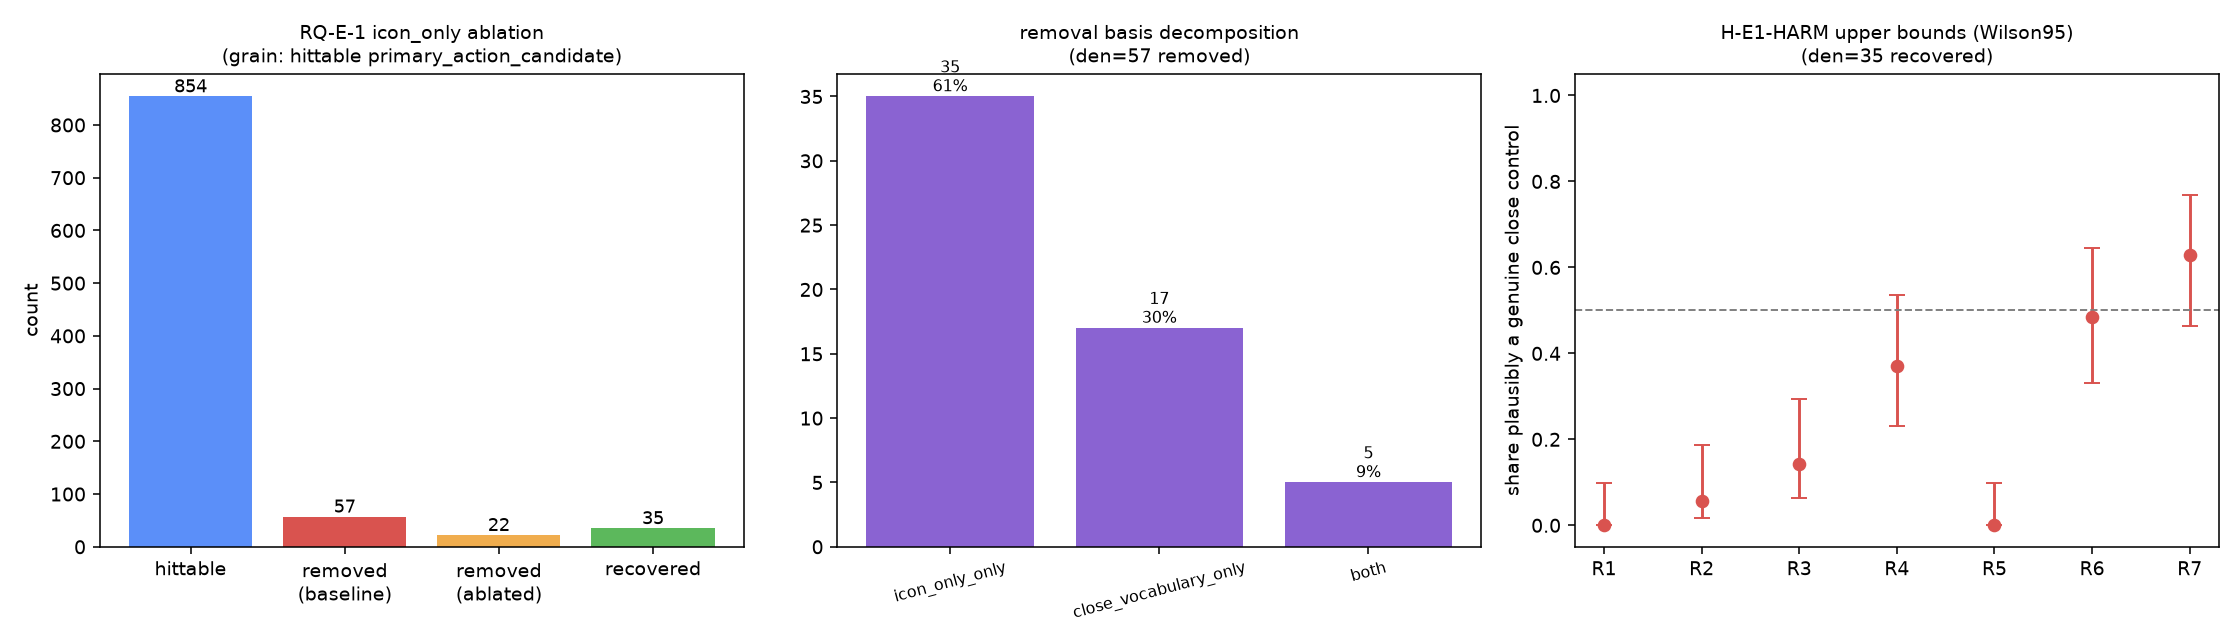

RQ_E1_per_target_pool.png


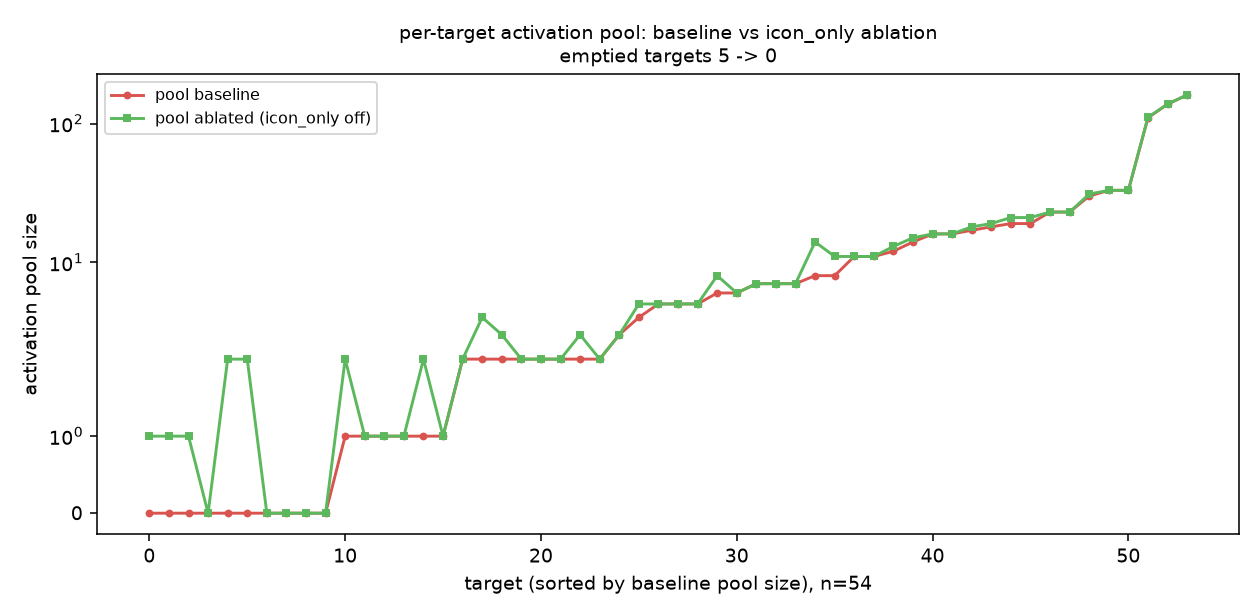

In [16]:
from IPython.display import Image, display
for f in sorted((RD / "figures").glob("RQ_E1_*.png")):
    print(f.name); display(Image(filename=str(f)))

In [17]:
out = RD / "results/RQ_E1_icononly_ablation.json"
saved = json.loads(out.read_text(encoding="utf-8"))
print("결과 파일:", out)
print("노트북 재계산과 저장본 일치 여부(핵심 수치):",
      saved["ablation_recovery"]["candidate_grain"]["n_recovered"] == cg["n_recovered"],
      saved["verdict"] == doc["verdict"],
      {k: v["verdict"] for k, v in saved["hypothesis_verdicts"].items()}
      == {k: v["verdict"] for k, v in doc["hypothesis_verdicts"].items()})
print("MLflow run_id:", saved.get("mlflow_run_id"))

결과 파일: /home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/results/RQ_E1_icononly_ablation.json
노트북 재계산과 저장본 일치 여부(핵심 수치): True True True
MLflow run_id: 2ae10cc3be9840e7a20c9fbc4ae23569
